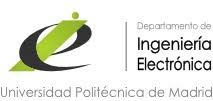

<div align="center">


# **Reconocimiento de gestos con la mano (Hand Gesture Recognition)**
### **Versión del 7 de Marzo de 2026**
---
---

</div>

In many contexts, having information about the movements of a person can be highly beneficial for diagnosing certain diseases. Parkinson's disease serves as a prime example, as it is a progressive disorder that affects the nervous system and impairs movement. In some cases, the disease initially manifests as subtle tremors that may not be visible to the naked eye but can be easily detected by an inertial sensor. To expand on the concept further, it is worth considering the utility of detecting landmarks from images and videos of individuals in real-time. Landmark detection involves identifying specific points or features of interest on a person's body, such as joints, facial landmarks, or key anatomical landmarks. These landmarks provide crucial information about the position, orientation, and movement of various body parts.  By leveraging computer vision techniques, cameras or video sensors can capture real-time images or video footage of individuals and detect the positions of these landmarks. This information can be invaluable for a wide range of applications, including  Gesture Recognition: Landmark detection enables the tracking and analysis of hand gestures or body movements. By recognizing specific patterns and trajectories of landmarks, it becomes possible to develop gesture recognition systems that can interpret and understand human movements.


1.   Biomechanical Analysis: Detecting landmarks from images or videos allows for the analysis of human biomechanics. By tracking the positions and movements of anatomical landmarks, it becomes possible to study and evaluate body mechanics, identify abnormalities, and aid in the diagnosis and treatment of musculoskeletal disorders.


2.   Physical Rehabilitation: Landmark detection can be employed in physical
rehabilitation settings to track and analyze a patient's movements during therapy sessions. By monitoring the positions and trajectories of specific landmarks, therapists can assess the progress of rehabilitation exercises and provide real-time feedback to patients.

3.  Human-Computer Interaction: By detecting landmarks, devices such as cameras or depth sensors can enable natural and intuitive interaction between humans and computers. This technology can facilitate applications like virtual reality, augmented reality, or touchless interfaces that respond to specific gestures or body movements.  To utilize landmark detection from images or video in real-time scenarios, advanced computer vision algorithms and techniques are employed.

These algorithms analyze the visual data, identify and track the desired landmarks, and extract meaningful information for further processing or application-specific tasks.


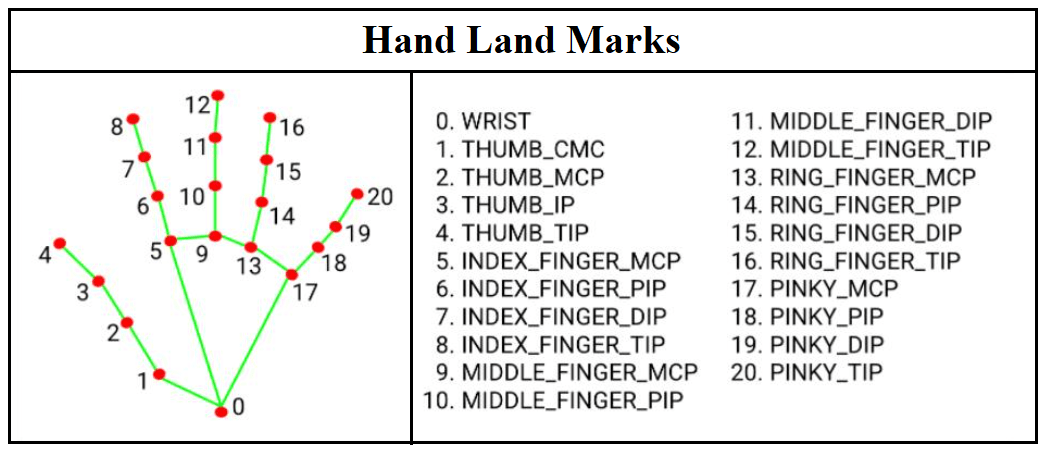






**Data Analysis**

For the purpose of our analysis, we will be working with the landmarks extracted from the images. These landmarks provide information about the position and orientation.
Our goal will be to develop models or perform analysis to discern between the different gestures based on the extracted landmarks. This could involve tasks such as gesture recognition, activity classification...


**Summary**

This practice is dedicated to the familiarization with the tools introduced during the course, more specifically, to mediapipe and Tensorflow.

The main concepts that we will work are:

1. Firstly, we will extract, interpret, and work with landmarks from different images. This involves extracting the relevant features or points of interest from the images and representing them as landmarks.
2. Secondly, we will train multiple models using the extracted landmarks. We will analyze the performance and predictions of each model, evaluating metrics such as accuracy, precision, recall, and F1-score. This step allows us to assess how well each model performs in recognizing and classifying gestures based on the landmarks
3. Thirdly, we will compare the performance of the different models and make any necessary adjustments or refinements. This may involve fine-tuning the models' hyperparameters, adding more data to improve generalization, or applying techniques to address specific challenges or limitations. The goal is to select the most suitable model that achieves the best overall performance in classifying the gestures based on the landmarks.

# Google Drive personal folder mount
The project will be executed in a folder that the student must upload to Google Drive with the database. The files generated throughout the practice, such as models, predictions, etc., will be saved in this folder


In [1]:
# Connect to Drive
from google.colab import drive
drive.mount('/content/drive')

# Clonar el repositorio sin descargar todo el contenido
!git clone --filter=blob:none --no-checkout https://github.com/efhes/IE-workspace.git

%cd IE-workspace

# Activar sparse checkout
!git sparse-checkout init --cone

# Seleccionar las carpetas necesarias
!git sparse-checkout set HAR_mediapipe common

# Descargar solo esas carpetas
!git checkout

Mounted at /content/drive
Cloning into 'IE-workspace'...
remote: Enumerating objects: 243, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 243 (delta 22), reused 22 (delta 10), pack-reused 199 (from 1)
Receiving objects: 100% (243/243), 37.80 KiB | 4.20 MiB/s, done.
Resolving deltas: 100% (85/85), done.
/content/IE-workspace
remote: Enumerating objects: 334, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 334 (delta 1), reused 36 (delta 1), pack-reused 288 (from 1)
Receiving objects: 100% (334/334), 157.81 MiB | 23.45 MiB/s, done.
Resolving deltas: 100% (6/6), done.
Updating files: 100% (337/337), done.
Your branch is up to date with 'origin/master'.


## Preparation

Let's start with installing MediaPipe.

In [1]:
!pip install -q mediapipe

zsh:1: /Users/ffm/workspace/IE-workspace/.venv-HAR_medipipe/bin/pip: bad interpreter: /Users/ffm/workspace/IE-workspace/.venv-1/bin/python3.13: no such file or directory


# Import required libraries

In this section, we will download and import all the neccessary packages for running the experiments.

Among the packages and libraries installed, the most important are:

* **Mediapipe** is an open-source framework developed by Google that provides a comprehensive pipeline for building multimodal (audio, video, and sensor) applications. It offers a wide range of pre-built and customizable machine learning models and processing modules, making it easier to develop complex multimedia applications.
* **pandas**: Python library that lets deal with csv and convert them to a DataFrame, type of data organization in a kind of table format.
* **tensorflow**: Open source software library for numerical computation using data-flow graphs and for implementing and training artificial neural networks.
* **numpy**: This Python library is oriented to make numeric operactions, algebra and mathematic analysis.
* **matplotlib**: This Python library contains graphic plot functions, similr to the resources available in Matlab for showing graphs.




In [45]:
!pip install mediapipe opencv-python tensorflow wandb scikit-learn pandas keras matplotlib seaborn

zsh:1: /Users/ffm/workspace/IE-workspace/.venv-HAR_medipipe/bin/pip: bad interpreter: /Users/ffm/workspace/IE-workspace/.venv-1/bin/python3.13: no such file or directory
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [ ]:
!pip install -r "/content/IE-workspace/HAR_mediapipe/requirements-HAR_mediapipe.txt"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 10.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.8/47.8 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.2 MB/s eta 0:00:00
Reason for being yanked: The Windows wheels, under some conditions, caused segfaults in unrelated user code.  Due to this we deleted the Windows wheels to prevent these segfaults, however this caused greater disruption as pip then began to try (and fail) to build 3.9.1 from the sdist on Windows which impacted far more users.  Yanking the whole release is the only tool available to eliminate these failures without changes to on the user side.  The sdist, OSX wheel, and manylinux wheels are all functional and there are no critical bugs in the release.   Downstream packagers should not yank their builds of Matplotlib 3.9.1.  See https://github.com/matplotlib/matplotlib/issu

We import proprietary libraries that will be utilized later:

From Colab

In [ ]:
import sys

sys.path.append('/content/IE-workspace/HAR_mediapipe/src/')
sys.path.append("/content/IE-workspace/common/")

import landmarksLib
print("Recursos de landmarksLib:", dir(landmarksLib)) # To check if it works

import config
print("Recursos de common:", dir(config)) # To check if it works

From desktop

In [46]:
%pip install tensorflow keras pandas numpy mediapipe opencv-python scikit-learn wandb matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import sys

# 1. Cambiar al directorio raíz del proyecto
%cd ~/workspace/IE-workspace/

# 2. Definir rutas ABSOLUTAS para evitar ambigüedades
root_path = os.getcwd()
path_har = os.path.join(root_path, "HAR_mediapipe", "src")
path_common = os.path.join(root_path, "common")

# 3. Añadirlas al path y verificar si existen
for p in [path_har, path_common]:
    if p not in sys.path:
        sys.path.append(p)
    if not os.path.exists(p):
        print(f"⚠️ ¡OJO! La ruta no existe: {p}")
    else:
        print(f"✅ Ruta añadida: {p}")

# 4. Intentar la importación
try:
    import landmarksLib
    print("🚀 landmarksLib importado con éxito")
except ModuleNotFoundError as e:
    print(f"❌ Error: {e}")
    
# 4. Intentar la importación
try:
    import config
    print("🚀 config importado con éxito")
except ModuleNotFoundError as e:
    print(f"❌ Error: {e}")

/Users/ffm/workspace/IE-workspace
✅ Ruta añadida: /Users/ffm/workspace/IE-workspace/HAR_mediapipe/src
✅ Ruta añadida: /Users/ffm/workspace/IE-workspace/common
🚀 landmarksLib importado con éxito
🚀 config importado con éxito


## Data folder specification

Links to the folder containing the database of images that will be used. **Please, note that the name of the subfolder containing the data must be updated accordingly if you wan to work with a different dataset.**

In [3]:
root_path = r'HAR_mediapipe/' # r'/content/IE-workspace/HAR_mediapipe/'

# Folder where the input data is saved
data_path = root_path + r'data/'
new_dataset_path = data_path + r'new_dataset/' # Change 'new_dataset' as needed
new_dataset_annotations_path = new_dataset_path + r'annotations/'
new_dataset_landmarks_path = new_dataset_path + r'landmarks/'
dataset_path = {}
dataset_path['train'] = new_dataset_path + r'train/'
dataset_path['test'] = new_dataset_path + r'test/'

# Folder where the models are stored
models_path = root_path + r'models/'

In [4]:
print('data_path = ', data_path)
print('new_dataset_path = ', new_dataset_path)
print('new_dataset_annotations_path = ', new_dataset_annotations_path)
print('new_dataset_landmarks_path = ', new_dataset_landmarks_path)
print('dataset_path[train] = ', dataset_path['train'])
print('dataset_path[test] = ', dataset_path['test'])
print('models_path = ', models_path)

data_path =  HAR_mediapipe/data/
new_dataset_path =  HAR_mediapipe/data/new_dataset/
new_dataset_annotations_path =  HAR_mediapipe/data/new_dataset/annotations/
new_dataset_landmarks_path =  HAR_mediapipe/data/new_dataset/landmarks/
dataset_path[train] =  HAR_mediapipe/data/new_dataset/train/
dataset_path[test] =  HAR_mediapipe/data/new_dataset/test/
models_path =  HAR_mediapipe/models/


## Landmark estimation and extraction

This code processes both train and test folders retrieving the images and processing them to obtain the corresponding landmarks.

In [60]:
import importlib
import landmarksLib  # La librería que ya tenías cargada
import evaluation

# Después de modificar el código de la librería:
importlib.reload(landmarksLib)
importlib.reload(evaluation)

<module 'evaluation' from '/Users/ffm/workspace/IE-workspace/common/evaluation.py'>

In [8]:
import os
from config import Config
from config import ConfigMediapipeDetector
from landmarksLib import GetLandmarksFromImages

detector_path = models_path + f'hand_landmarker.task' #'/content/IE-workspace/HAR_mediapipe/models/hand_landmarker.task'

if __name__ == '__main__':
  config = Config(save_images=True) #False)

  # Create the detector
  detector = ConfigMediapipeDetector(detector_path)

  num_successful_detections = {}
  num_successful_detections['train'] = {}
  num_successful_detections['test'] = {}
  num_failed_detections = {}
  num_failed_detections['train'] = {}
  num_failed_detections['test'] = {}

  for mode in ['train', 'test']:
    print('\n[Processing input data...][%s]' % mode)
    for images_class in os.listdir(dataset_path[mode]):
      print('\n\t[New class][%s]' % images_class) # ok

      #images_symbol_path = os.path.join(original_data_path, symbol)
      class_folder_path = os.path.join(dataset_path[mode], images_class)
      print('\t[Folder][%s]' % class_folder_path) # ok

      IMAGE_FILES = os.listdir(class_folder_path)

      (df_successful_detections,
      num_successful_detections[mode][images_class],
      num_failed_detections[mode][images_class] ) = GetLandmarksFromImages(
          detector,
          IMAGE_FILES,
          dataset_path[mode], # Folder where the images are stored
          mode, # This is the subfolder where the images are stored (train/test)
          images_class, # This is the class of the images (e.g., 'class1', 'class2', etc.)
          new_dataset_landmarks_path, # Folder where the landmarks will be saved
          new_dataset_annotations_path, # Folder where the annotations will be saved
          config)

  print('\n[SUMMARY OF SUCCESSFUL DETECTIONS]')
  num_total_ok = 0
  num_total_wrong = 0
  for mode in ['train', 'test']:
    for class_folder in os.listdir(dataset_path[mode]):
      num_total_ok = num_total_ok + num_successful_detections[mode][class_folder]
      num_total_wrong = num_total_wrong + num_failed_detections[mode][class_folder]
      print('\t[%s][%s][%d out of %d][%0.2f]' % (mode, class_folder,
        num_successful_detections[mode][class_folder],
        num_successful_detections[mode][class_folder]+num_failed_detections[mode][class_folder],
        100*num_successful_detections[mode][class_folder]/(num_successful_detections[mode][class_folder]+num_failed_detections[mode][class_folder])))

  print('[NUM TOTAL SUCCESSFUL = %d][%0.2f]' % (num_total_ok, 100*num_total_ok/(num_total_ok+num_total_wrong)))
  print('[NUM TOTAL FAILED = %d][%0.2f]' % (num_total_wrong, 100*num_total_wrong/(num_total_ok+num_total_wrong)))

I0000 00:00:1772992666.914435 5029738 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Pro
W0000 00:00:1772992666.919523 5029739 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1772992666.924465 5029751 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.



[Processing input data...][train]

	[New class][right]
	[Folder][HAR_mediapipe/data/new_dataset/train/right]
	[New .csv file with landmarks][HAR_mediapipe/data/new_dataset/landmarks//train//train_right_poses_landmarks.csv]

[GetLandmarksFromImages]
	[files][['right_00023.jpg', 'right_00022.jpg', 'right_00008.jpg', 'right_00034.jpg', 'right_00020.jpg', 'right_00021.jpg', 'right_00035.jpg', 'right_00009.jpg', 'right_00031.jpg', 'right_00025.jpg', 'right_00019.jpg', 'right_00018.jpg', 'right_00024.jpg', 'right_00030.jpg', 'right_00026.jpg', 'right_00032.jpg', 'right_00033.jpg', 'right_00027.jpg', 'right_00002.jpg', 'right_00016.jpg', 'right_00017.jpg', 'right_00003.jpg', 'right_00029.jpg', 'right_00015.jpg', 'right_00001.jpg', 'right_00014.jpg', 'right_00028.jpg', 'right_00010.jpg', 'right_00004.jpg', 'right_00005.jpg', 'right_00011.jpg', 'right_00007.jpg', 'right_00013.jpg', 'right_00012.jpg', 'right_00006.jpg']]
	[input images in path][HAR_mediapipe/data/new_dataset/train/]
	[landmarks

## Functions for pre-processing and loading data

In [9]:
import pandas as pd
import numpy as np
import os


# Create file CSV and Numpy
def create_numpy_with_feats_and_csv_with_just_labels(input_mode, new_dataset_path, NO_GESTURE=False):
  if NO_GESTURE:
    aux = '_plus_NO_GESTURE'
  else:
    aux = ''

  print('\n[create_numpy_with_feats_and_csv_with_just_labels][%s]' % input_mode)
  input_file = new_dataset_path + '/' + input_mode + '_dataset_with_labels' + aux + '.csv'
  print('\t[input_file][%s]' % input_file)
  df = pd.read_csv(input_file)
  num_points = 42

  new_df = pd.DataFrame([], columns=["frame", "label"])
  data = np.zeros((len(df), num_points))
  fea_list = [["x" + str(j), "y" + str(j)] for j in range(int(num_points / 2))]
  flat_fea_list = [item for sublist in fea_list for item in sublist]

  for i in range(len(df)):
      data[i] = df.loc[i][flat_fea_list]
      new_df.loc[i] = [df["frame"][i], df["label"][i]]

  # Save NEW .csv which includes just the labels information
  new_csv_filename = new_dataset_path + '/' + input_mode + '_labels' + aux + '.csv'
  print('\t[NEW .csv][%s]' % new_csv_filename)
  new_df.to_csv(new_csv_filename, index=False)

  # Save NEW .npy which includes only the features
  new_npy_filename = new_dataset_path + '/' + input_mode + '_dataset' + aux + '.npy'
  print('\t[NEW .npy][%s]' % new_npy_filename)
  np.save(new_npy_filename, data)

## Data pre-processing

In summary, the code creates a CSV file with the coordinates of the landmarks. Then, it loads a CSV file with point coordinates, processes the data, and creates a new DataFrame and a numpy file that contain the transformed and labeled data for further analysis or model training.
We will have the two CSV files and the .npy file in our landmarks folder.

In [16]:
from landmarksLib import extract_classes_list_from_folders, sorted_lists_match, load_individual_class_features_and_create_labeled_csv_dataset

# Make the following True if you want your model to include a NO_GESTURE class
plus_NO_GESTURE = True

# Execute once!
print("Loading data...")

classes_train = extract_classes_list_from_folders(dataset_path['train'], new_dataset_path)
classes_test = extract_classes_list_from_folders(dataset_path['test'], new_dataset_path)

print('\n[TRAIN]', classes_train)
print('[TEST]', classes_train)

if sorted_lists_match(classes_train, classes_test) == False:
  print('\n[ERROR!!!]\n[extract_classes_list_from_folders][sorted_lists_match][False]\n')
  exit()

load_individual_class_features_and_create_labeled_csv_dataset('train', new_dataset_path, new_dataset_landmarks_path)
load_individual_class_features_and_create_labeled_csv_dataset('test', new_dataset_path, new_dataset_landmarks_path)

create_numpy_with_feats_and_csv_with_just_labels('train', new_dataset_path)
create_numpy_with_feats_and_csv_with_just_labels('test', new_dataset_path)

Loading data...

[extract_classes_list_from_folders][NEW .txt file]
	[HAR_mediapipe/data/new_dataset//train_classes_list.txt]

[extract_classes_list_from_folders][NEW .txt file]
	[HAR_mediapipe/data/new_dataset//test_classes_list.txt]

[TRAIN] ['backward', 'forward', 'left', 'right', 'shoot', 'stop']
[TEST] ['backward', 'forward', 'left', 'right', 'shoot', 'stop']

[load_individual_class_features_and_create_labeled_csv_dataset][train]
	[LOAD .txt file with the list of classes][HAR_mediapipe/data/new_dataset//train_classes_list.txt]
	[LOAD .csv file with landmarks][HAR_mediapipe/data/new_dataset/landmarks/train/train_backward_poses_landmarks.csv]
	[LOAD .csv file with landmarks][HAR_mediapipe/data/new_dataset/landmarks/train/train_forward_poses_landmarks.csv]
	[LOAD .csv file with landmarks][HAR_mediapipe/data/new_dataset/landmarks/train/train_left_poses_landmarks.csv]
	[LOAD .csv file with landmarks][HAR_mediapipe/data/new_dataset/landmarks/train/train_right_poses_landmarks.csv]
	[LOAD

## Adding *'NO_GESTURE'* extra class  (optional)

We can try reading the files that were previously generated

In [17]:
# Number of classes
data_path = new_dataset_path
classes_list = pd.read_csv(data_path + '/' + 'train_classes_list.txt', header=None)
num_classes = len(classes_list)

print(f'\n[NUM CLASSES = {num_classes} classes]')


[NUM CLASSES = 6 classes]


In [18]:
# Read csv
for input_mode in ['train', 'test']:
  filename = new_dataset_path + '/' + input_mode + '_dataset_with_labels.csv'
  df = pd.read_csv(filename)
  print('\n[Showing][%s]' % filename)
  print(df)


[Showing][HAR_mediapipe/data/new_dataset//train_dataset_with_labels.csv]
           x0        y0        x1        y1        x2        y2        x3  \
0    0.399486  0.573909  0.404269  0.522988  0.405311  0.463909  0.407137   
1    0.382919  0.653526  0.405513  0.612541  0.405745  0.559336  0.405877   
2    0.391774  0.598540  0.411814  0.565047  0.411470  0.519481  0.410827   
3    0.397305  0.581125  0.415985  0.548732  0.414778  0.505787  0.413936   
4    0.396149  0.565602  0.394088  0.511948  0.394451  0.454845  0.398101   
..        ...       ...       ...       ...       ...       ...       ...   
197  0.421021  0.638619  0.474731  0.620488  0.511048  0.555948  0.531829   
198  0.431582  0.542379  0.475568  0.519257  0.506421  0.464589  0.522986   
199  0.509029  0.567959  0.561266  0.545205  0.588539  0.481399  0.600946   
200  0.310891  0.701174  0.362535  0.661069  0.397225  0.582296  0.410518   
201  0.303071  0.630885  0.344210  0.600123  0.371837  0.542144  0.382540   

 

In [19]:
# Add as many new examples as there are examples from other classes
num_samples_per_class = df['label'].value_counts()
np.mean(num_samples_per_class)
average_num_samples_per_class = int(np.mean(num_samples_per_class))
print('num_samples_per_class')
print(num_samples_per_class)
print('average_num_samples_per_class = ', average_num_samples_per_class)

num_samples_per_class
label
1.0    15
3.0    15
4.0    15
6.0    15
2.0    14
5.0     7
Name: count, dtype: int64
average_num_samples_per_class =  13


This is where the magic actually happens

In [20]:
no_gesture_class = num_classes + 1
num_landmarks_coordinates = config.num_landmarks * 2

for input_mode in ['train', 'test']:
  input_filename = new_dataset_path + '/' + input_mode + '_dataset_with_labels.csv'
  print('\n[LOAD .csv file][%s]' % input_filename)
  df = pd.read_csv(input_filename)

  # Add as many new examples as there are examples from other classes
  num_samples_per_class = df['label'].value_counts()
  average_num_samples_per_class = int(np.mean(num_samples_per_class))

  # Create the new row
  new_row = pd.DataFrame([[0]*num_landmarks_coordinates + [no_gesture_class] + ['NO_GESTURE'] + ['No gesture - No URL']], columns=df.columns)

  # These are for the NO GESTURE class; We add as many new rows as average_num_samples_per_class
  for i in range(average_num_samples_per_class):
      df = pd.concat([df,new_row], ignore_index=True)

  print('\t[%d NEW samples for NO GESTURE class]' % average_num_samples_per_class)

  # Save
  output_filename = new_dataset_path + '/' + input_mode + '_dataset_with_labels_plus_NO_GESTURE.csv'
  print('\n[NEW .csv file][%s]' % output_filename)
  df.to_csv(output_filename, index=False)

  # We can now reutilize 'create_numpy_with_feats_and_csv_with_just_labels'
  # to create coherent .npy and .csv files
  create_numpy_with_feats_and_csv_with_just_labels(input_mode, new_dataset_path, NO_GESTURE=True)



[LOAD .csv file][HAR_mediapipe/data/new_dataset//train_dataset_with_labels.csv]
	[33 NEW samples for NO GESTURE class]

[NEW .csv file][HAR_mediapipe/data/new_dataset//train_dataset_with_labels_plus_NO_GESTURE.csv]

[create_numpy_with_feats_and_csv_with_just_labels][train]
	[input_file][HAR_mediapipe/data/new_dataset//train_dataset_with_labels_plus_NO_GESTURE.csv]
	[NEW .csv][HAR_mediapipe/data/new_dataset//train_labels_plus_NO_GESTURE.csv]
	[NEW .npy][HAR_mediapipe/data/new_dataset//train_dataset_plus_NO_GESTURE.npy]

[LOAD .csv file][HAR_mediapipe/data/new_dataset//test_dataset_with_labels.csv]
	[13 NEW samples for NO GESTURE class]

[NEW .csv file][HAR_mediapipe/data/new_dataset//test_dataset_with_labels_plus_NO_GESTURE.csv]

[create_numpy_with_feats_and_csv_with_just_labels][test]
	[input_file][HAR_mediapipe/data/new_dataset//test_dataset_with_labels_plus_NO_GESTURE.csv]
	[NEW .csv][HAR_mediapipe/data/new_dataset//test_labels_plus_NO_GESTURE.csv]
	[NEW .npy][HAR_mediapipe/data/new

In [21]:
filename = new_dataset_path + '/' + 'test' + '_labels_plus_NO_GESTURE.csv'
print('\n[Showing][%s]' % filename)
df = pd.read_csv(filename)
df


[Showing][HAR_mediapipe/data/new_dataset//test_labels_plus_NO_GESTURE.csv]


,frame,label
0,49,1.0
1,48,1.0
2,38,1.0
3,39,1.0
4,37,1.0
...,...,...
89,NO_GESTURE,7.0
90,NO_GESTURE,7.0
91,NO_GESTURE,7.0
92,NO_GESTURE,7.0


In [22]:
filename = new_dataset_path + '/' + 'test' + '_dataset_plus_NO_GESTURE.npy'
print('\n[Loading][%s]' % filename)
data = np.load(filename)
data.shape


[Loading][HAR_mediapipe/data/new_dataset//test_dataset_plus_NO_GESTURE.npy]


(94, 42)

# Normalization

Execute only once, do not execute with each network change!!!!!!!!

In [ ]:
# This function takes a NumPy array data as input and returns a new array new_data with normalized landmarks.
# In summary, this function takes hand landmark data, assumes that the first two coordinates represent
# the center of the hand, and shifts the remaining landmarks' coordinates so that the center becomes the new origin.
# This can be useful for normalizing hand landmark data for further analysis or processing.
def normalize_from_0_landmark(data):
  # We create a copy of the input data array to ensure that the original data is not modified,
  # and the modifications are made to the copy
  new_data = np.copy(data)
  # This loop iterates through each row of the data array.
  # Each row represents a different hand instance or sample.
  for i in range(data.shape[0]):
    # This condition helps to skip rows where the sum of X and Y coordinates is zero,
    # which may represent a case where there are no landmarks.
    if ((data[i, 0] + data[i, 1]) != 0):
      # These lines extract the X and Y coordinates of the center of the hand landmarks (typically, the palm).
      x_center = data[i, 0]
      y_center = data[i, 1]
      # This inner loop iterates through the remaining elements of the row,
      # starting from the third element (index 2).
      # In hand landmark data, these are typically the landmarks' X and Y coordinates, alternating.
      for k in range(2, data.shape[1], 2):
        # These lines calculate the new coordinates of each landmark relative to the center.
        # They subtract the center's X and Y coordinates from the corresponding landmark's X and Y coordinates.
        # This effectively shifts the coordinates so that the center becomes the new origin (0, 0).
        new_data[i, k] = data[i, k] - x_center
        new_data[i, k + 1] = data[i, k + 1] - y_center
  return new_data

# Important functions for training

## Model definition

We will analyze the performance of four models:

*   two CNN models with a simple structure and another with a more complex structure,
*   a network using fine-tuning by leveraging the weights of the best model from the previous models,
*   and a final model using fine-tuning while freezing certain layers.

In [23]:
def DefineNetworkModel(num_classes, num_cnn_features, network_type, num_channels):
  print('\tnum_classes = %d' % num_classes)
  print('\tnum_cnn_features = %d' % num_cnn_features)
  print('\tnum_channels = %d' % num_channels)
  print('\tnetwork_type = %s' % network_type)

  if (network_type == "CNN1"):
    model = Sequential()
    # We start by adding a convolutional layer to our model
    # arg 1: Number of filters (features) that the convolutional layer will learn.
    #   Each filter extracts different features from the input.
    # arg 2: Filter size in the form (height, width). In this case, it's a filter with a height of 5 and a width of 1.
    #   The height usually captures vertical details, and the width captures horizontal details.
    # arg 3: The padding parameter controls how the image border is handled.
    #   'same' ensures that the output size is the same as the input size by padding with zeros if needed.
    # arg 4: This is the shape of the input data. num_channels refers to the number of channels
    #   (typically 1 for grayscale or 3 for RGB color images), and here it's divided by 2 to represent hand landmarks
    #   (which are stored as X and Y coordinates in a single channel).
    #   (2, 1) represents the size of the feature window (in this case, a window of 2 rows and 1 column).
    # arg 5: This specifies the activation function to use after applying the convolution.
    #   'relu' is a common activation function that sets negative values to zero and leaves positive values unchanged.
    model.add(Conv2D(num_cnn_features,
      (5, 1),
      padding='same',
      input_shape=(int(num_channels / 2), 2, 1),
      activation='relu'))

    # model.add(MaxPooling2D(pool_size=(2, 1)))
    model.add(Dropout(dropout))
    # model.add(Conv2D(num_cnn_features, (5, 1),padding='same', activation='relu'))
    # model.add(MaxPooling2D(pool_size=(2, 1)))
    # model.add(Dropout(dropout))
    model.add(Flatten())
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(dropout))
    model.add(Dense(num_classes, activation='softmax'))
  elif (network_type == "CNN2"):
    model = Sequential()
    model.add(Conv2D(num_cnn_features,
      (3, 3),
      padding='same',
      input_shape=(int(num_channels / 2), 2, 1),
      activation='sigmoid'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(32, activation='relu'))  # Reduce the number of units in the dense layer
    model.add(Dropout(dropout))
    model.add(Dense(num_classes, activation='softmax'))
  elif (network_type == "FINE-TUNING1"):
    model = Sequential()
    model.add(Conv2D(num_cnn_features, (5, 1), padding='same', input_shape=(int(num_channels / 2), 2, 1), activation='relu'))
    model.add(Dropout(dropout))
    model.add(Flatten())
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(dropout))
    # Carga los pesos del modelo original desde el fichero
    model.load_weights(load_model, by_name=True)
    # añadir capa final con mis clases
    model.add(Dense(num_classes, activation='softmax'))
  elif (network_type == "FINE-TUNING2"):
    model = Sequential()
    model.add(Conv2D(num_cnn_features, (5, 1), padding='same', input_shape=(int(num_channels / 2), 2, 1), activation='relu'))
    model.add(Dropout(dropout))
    model.add(Flatten())
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(dropout))

    # Carga los pesos del modelo original desde el fichero
    model.load_weights(load_model, by_name=True)
    #añadir capa final con mis clases
    model.add(Dense(num_classes, activation='softmax'))

    # Congelar algunas capas
    for layer in model.layers[:3]:
        layer.trainable = False

  print('\n[MODEL SUMMARY]')
  model.summary()

  return model

## Specific data arrangement

In [24]:
def ArrangeInputDataForNetwork (x_data):
  if debug:
    print('x_data')
    print(x_data.shape)
    print(x_data)

  x_data_reshaped = np.zeros((x_data.shape[0],
                              int(x_data.shape[1] / 2),
                              2))
  if debug:
    print('x_data_reshaped')
    print(x_data_reshaped.shape)
    print(x_data_reshaped)

  for i in range(len(x_data)):
    x_data_reshaped[i, :, 0] = x_data[i, 0::2]
    x_data_reshaped[i, :, 1] = x_data[i, 1::2]

  x_data_out = np.reshape(x_data_reshaped, (x_data_reshaped.shape[0], x_data_reshaped.shape[1], x_data_reshaped.shape[2], 1))

  if debug:
    print('x_data_out')
    print(x_data_out.shape)
    print(x_data_out)

  return x_data_out

# Model Training

Execute once for each change in the type of network.

### Data preparation for conventional training with train and test lists

In [35]:
import random

print('\n[DATA PREPARATION]')

debug = False
norm_type = None

if plus_NO_GESTURE:
  aux = '_plus_NO_GESTURE'
else:
  aux = ''

# First we read the numpy file for train
filename = new_dataset_path + '/' + 'train' + '_dataset' + aux + '.npy'
print('\t[Loading][%s]' % filename)
train_data = np.load(filename)
if debug:
  print('train_data.shape =', train_data.shape)

if norm_type == "L0":
  normalized_train_data = normalize_from_0_landmark(train_data)
  train_data = normalized_train_data

# First we read the numpy file for test
filename = new_dataset_path + '/' + 'test' + '_dataset' + aux + '.npy'
print('\t[Loading][%s]' % filename)
test_data = np.load(filename)
if debug:
  print('test_data.shape =', test_data.shape)

if norm_type == "L0":
  normalized_test_data = normalize_from_0_landmark(test_data)
  test_data = normalized_test_data

# Then we read the csv file for train
filename = new_dataset_path + '/' + 'train' + '_dataset_with_labels' + aux + '.csv'
train_new_df = pd.read_csv(filename)
print('\t[Loading][%s]' % filename)
if debug:
  print(train_new_df)

# Then we read the csv file for test
filename = new_dataset_path + '/' + 'test' + '_dataset_with_labels' + aux + '.csv'
test_new_df = pd.read_csv(filename)
print('\t[Loading][%s]' % filename)
if debug:
  print(test_new_df)

x_train_data = train_data
y_train_data = np.array(train_new_df["label"])

if debug:
  print('y_train_data (BEFORE SHUFFLING)')
  print(y_train_data)

x_test_data = test_data
y_test_data = np.array(test_new_df["label"])

if debug:
  print('y_test_data')
  print(y_test_data)

# We shuffle the training data
temp = list(zip(x_train_data, y_train_data))
random.shuffle(temp)
res1, res2 = zip(*temp)
x_train_data, y_train_data = np.asarray(list(res1)), np.asarray(list(res2))

if debug:
  print('y_train_data (AFTER SHUFFLING)')
  print(y_train_data)

# num_classes + 1 is to include the NO GESTURE class
y_train_data_format = np.zeros((y_train_data.shape[0], num_classes + 1), dtype=int)
if debug:
  print('y_train_data_format.shape', y_train_data_format.shape)

y_test_data_format = np.zeros((y_test_data.shape[0], num_classes + 1), dtype=int)
if debug:
  print('y_test_data_format.shape', y_test_data_format.shape)

if debug:
  print('y_train_data_format')
  print(y_train_data_format)

for j in range(y_train_data.shape[0]):
    y_train_data_format[j, int(y_train_data[j]) - 1] = 1

for j in range(y_test_data.shape[0]):
    y_test_data_format[j, int(y_test_data[j]) - 1] = 1

if debug:
  print('y_train_data_format')
  print(y_train_data_format)

x_train = ArrangeInputDataForNetwork (x_train_data)
x_test = ArrangeInputDataForNetwork (x_test_data)

print('[DATA PREPARATION FINISHED!!!]')


[DATA PREPARATION]
	[Loading][HAR_mediapipe/data/new_dataset//train_dataset_plus_NO_GESTURE.npy]
	[Loading][HAR_mediapipe/data/new_dataset//test_dataset_plus_NO_GESTURE.npy]
	[Loading][HAR_mediapipe/data/new_dataset//train_dataset_with_labels_plus_NO_GESTURE.csv]
	[Loading][HAR_mediapipe/data/new_dataset//test_dataset_with_labels_plus_NO_GESTURE.csv]
[DATA PREPARATION FINISHED!!!]


## Common training parameters

Execute only once, do not execute with each network change!!!!!!!!

In [ ]:
# Parameters
np.random.seed(2022)
num_channels = 42
batch_size = 32
epochs = 300
dropout = 0.3
num_cnn_features = 16
patience = 50 # Número de épocas sin mejora antes de detener el entrenamiento
norm_type = "None" # Current version of Mediapipe provides already normalized landmarks
#norm_type = "L0"
k = 10

In [26]:
# List where to save the results you want to display to compare metrics
model_results = []

## Model definition and training

#### 🔹 Optimizer Comparison in Keras

| **Optimizer** | **Recommended for** | **Suggested Initial Learning Rate** | **Usage Code** |
|--------------|---------------------|----------------------------------|--------------|
| **Adam** (🔥 Best general choice) | Complex models, large datasets, CNNs, and MLPs | `0.001` | `Adam(learning_rate=0.001)` |
| **RMSprop** | Sequential data, RNNs/LSTMs, unstable gradients | `0.0005` | `RMSprop(learning_rate=0.0005)` |
| **SGD with momentum** | Models that need better generalization | `0.01` | `SGD(learning_rate=0.01, momentum=0.9)` |
| **AdamW** | Deep networks, noisy datasets, overfitting issues | `0.001`, with `weight_decay=1e-4` | `AdamW(learning_rate=0.001, weight_decay=1e-4)` |


In [ ]:
import time
from keras.models import Sequential, Model
from keras.layers import Input, Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, Conv3D, MaxPooling2D, MaxPooling3D, Reshape
from keras.layers import LSTM, SimpleRNN, GRU, BatchNormalization
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, roc_curve, auc
from keras.optimizers import AdamW
from keras.callbacks import EarlyStopping

print('\n[DefineNetworkModel]')

# Types: "CNN1","CNN2", "FINE-TUNING1", "FINE-TUNING2"
network_type = "CNN1"
#network_type = "CNN2"
#network_type = "FINE-TUNING1"
#network_type = "FINE-TUNING2"

# Everything is referred to 'data_path' which was originally set to 'new_dataset_path'
models_folder = data_path + '/' + 'models/'

# In case of using fine-tunning load weights of the trained model with CNN1
load_model = models_path + r'poses.h5'

# REMEMBER: num_classes + 1 is to include the NO GESTURE class
model = DefineNetworkModel(num_classes+1, num_cnn_features, network_type, num_channels)

# Definir el criterio de parada temprana
early_stopping = EarlyStopping(
    monitor='val_loss',  # Puedes cambiarlo a 'val_accuracy' si prefieres
    patience=patience,          # Número de épocas sin mejora antes de detener el entrenamiento
    restore_best_weights=True,  # Restaurar los mejores pesos del modelo
    verbose=1
)

# opt=tf.keras.optimizers.SGD(lr=0.001)
# opt=tf.keras.optimizers.RMSprop(lr=0.0005, rho=0.9, epsilon=1e-08, decay=0.0)
opt = AdamW(learning_rate=0.001, weight_decay=1e-4)  # Ajusta el weight decay según el problema
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

print('\n[model.fit][Training starts!]\n')
start_time = time.time()

# Training with Early Stopping
history = model.fit(x_train,
                    y_train_data_format,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    shuffle=True,
                    validation_data=(x_test, y_test_data_format),  # Asegúrate de tener datos de validación
                    callbacks=[early_stopping])


[DefineNetworkModel]
	num_classes = 7
	num_cnn_features = 16
	num_channels = 42
	network_type = CNN1

[MODEL SUMMARY]


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 21, 2, 16)      │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 21, 2, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 672)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │        21,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,863 (85.40 KB)

 Trainable params: 21,863 (85.40 KB)

 Non-trainable params: 0 (0.00 B)


[model.fit][Training starts!]

Epoch 1/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.1702 - loss: 1.9399 - val_accuracy: 0.1596 - val_loss: 1.9013
Epoch 2/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2085 - loss: 1.8873 - val_accuracy: 0.3085 - val_loss: 1.8520
Epoch 3/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3404 - loss: 1.8695 - val_accuracy: 0.5745 - val_loss: 1.8100
Epoch 4/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4170 - loss: 1.8098 - val_accuracy: 0.6170 - val_loss: 1.7706
Epoch 5/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3830 - loss: 1.7742 - val_accuracy: 0.5319 - val_loss: 1.7287
Epoch 6/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3787 - loss: 1.7506 - val_accuracy: 0.5957 - val_loss: 1.6791
Epoch 7/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4213 - loss: 1.6725 - val_accuracy: 0.5957 - val_loss: 1.6127
Epoch 8/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4553 - loss: 1.6017 - val_acc

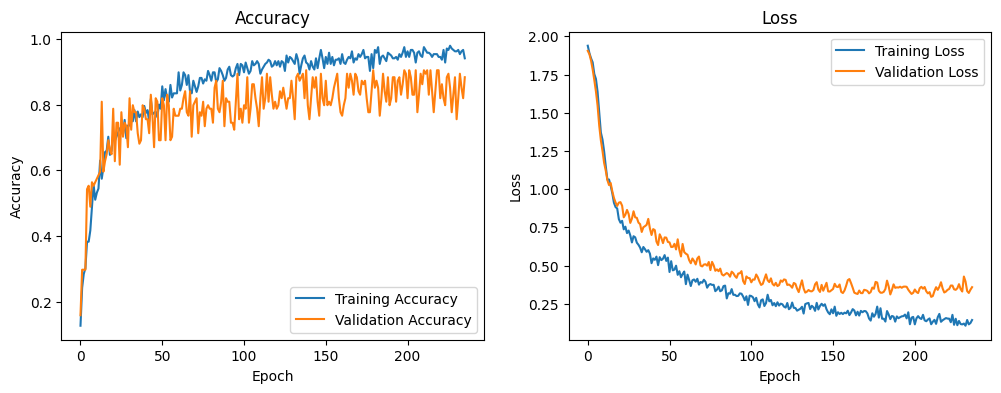

In [37]:
# prompt: plot learning curves

import matplotlib.pyplot as plt

# Assuming 'history' is the output of model.fit
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


Performance analysis:

In [38]:
print('\n[PERFORMANCE ANALYSIS]')
print('[SETUP]')
print('\t[Normalization: %s]' % norm_type)
print('\t[Type of network: %s]' % network_type)
print('\t[Num classes: %d]' % num_classes)

# For train data
predictions = model.predict(x_train, batch_size = batch_size, verbose = 1)
y_pred_train = np.argmax(predictions, axis=1)
y_true_train = np.argmax(y_train_data_format, axis=1)
print('y_pred_train', y_pred_train)
print('y_true_train', y_true_train)
matrix = confusion_matrix(y_true_train, y_pred_train) #, labels=np.arange(1, num_classes + 1))

print('[Number of training examples = %d]' % matrix.sum())
print('\n[Confusion matrix for training data]')
print(matrix)
print('\n[Train accuracy = %0.4f]' % accuracy_score(y_true_train, y_pred_train))
print('[Train unweighted f-measure = %0.4f]' % f1_score(y_true_train, y_pred_train, average='macro'))
print('[Train weighted f-measure = %0.4f]' % f1_score(y_true_train, y_pred_train, average='weighted'))

# For test data
prediction = model.predict(x = x_test, batch_size = batch_size, verbose = 1)
y_pred_test = np.argmax(prediction, axis=1)
y_true_test = np.argmax(y_test_data_format, axis=1)
print('y_pred_test', y_pred_test)
print('y_true_test', y_true_test)
matrix = confusion_matrix(y_true_test, y_pred_test) #, labels=np.arange(1, num_classes+1))

print('[Number of test examples = %d]' % matrix.sum())
print('\n[Confusion matrix for test data]')
print(matrix)
print('\n[Test accuracy = %0.4f]' % accuracy_score(y_true_test, y_pred_test))
print('[Test unweighted f-measure = %0.4f]' % f1_score(y_true_test, y_pred_test, average='macro'))
print('[Test weighted f-measure = %0.4f]' % f1_score(y_true_test, y_pred_test, average='weighted'))

end_time = time.time()
execution_time = end_time - start_time

model_results.append({
    "model_type": network_type,
    "norm_type": norm_type,
    "accuracy": accuracy_score(y_true_test, y_pred_test),
    "f-measure_unweighted": f1_score(y_true_test, y_pred_test, average='macro'),
    "f-measure_weighted": f1_score(y_true_test, y_pred_test, average='weighted'),
    "execution_time": execution_time
  })


[PERFORMANCE ANALYSIS]
[SETUP]
	[Normalization: None]
	[Type of network: CNN1]
	[Num classes: 6]
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
y_pred_train [1 2 5 0 0 1 2 3 3 3 1 0 6 4 4 0 0 6 4 3 4 6 2 2 0 2 1 3 4 4 6 5 6 6 4 3 6
 3 5 6 1 2 0 2 6 1 2 0 0 2 1 0 1 5 1 3 1 3 6 1 3 0 2 1 2 4 4 2 6 0 6 6 5 3
 5 2 3 4 2 5 5 6 5 0 2 5 5 3 3 3 2 3 2 5 5 5 4 4 1 0 0 4 3 5 1 1 5 1 6 0 2
 5 6 2 1 0 4 2 5 4 0 4 6 6 3 0 6 4 2 3 0 6 0 6 2 5 3 6 0 0 4 0 6 6 0 4 2 3
 2 1 3 5 3 4 5 4 1 1 4 0 4 5 6 0 3 6 0 0 5 2 0 0 4 0 5 6 5 4 2 5 4 1 2 2 3
 3 2 4 5 3 3 2 5 4 4 5 4 6 1 3 5 1 1 5 0 1 0 5 1 2 1 4 6 2 6 2 6 3 2 3 1 3
 5 1 2 6 5 3 5 3 2 0 3 6 1]
y_true_train [1 2 5 0 0 1 2 3 3 3 1 0 6 4 4 0 0 6 4 3 4 6 2 2 0 2 1 3 4 4 6 5 6 6 4 3 6
 3 5 6 1 2 0 2 6 1 2 0 0 2 1 0 1 5 1 3 1 3 6 1 3 0 2 1 2 4 4 4 6 0 6 6 5 3
 5 2 3 4 2 5 5 6 5 0 2 5 5 3 3 3 2 3 2 5 5 5 4 4 1 0 0 4 3 5 1 1 5 1 6 0 2
 5 6 2 1 0 4 2 5 4 0 4 6 6 3 0 6 4 2 3 0 6 0 6 2 5 3 6 0 0 4 0 6 6 0 4 2 3
 2 1 3 5 3 4 5 4 1 1 4 0 4 5 6 0 3 6 0 0 5 2 0 0 4 0 5 6 5 4

### Model Saving
To save data in your Collab in folder 'models'.

In [40]:
# First we serialize model to JSON
model_json = model.to_json()

# Second we check whether folder for models exists or not
if not os.path.exists(models_path):
    os.makedirs(models_path)

# Third we define the root filename which will be used when creating the model files
root_filename = 'new_model'

if norm_type == 'L0':
  aux = '_L0'
else:
  aux = ''

# Fourth we save the model description
json_filename = os.path.join(models_path, f"{root_filename}_{network_type}{aux}.json")
print(f'[SAVING MODEL DESCRIPTION][{json_filename}]')
with open(json_filename, 'w') as json_file:
    json_file.write(model_json)

# Save model using the **new recommended Keras format**
keras_filename = os.path.join(models_path, f"{root_filename}_{network_type}{aux}.keras")
print(f'[SAVING MODEL][{keras_filename}]')
model.save(keras_filename)  # ✅ Uses `.keras` format instead of `.h5`

print('[MODEL SAVED!!!]')

[SAVING MODEL DESCRIPTION][HAR_mediapipe/models/new_model_CNN1.json]
[SAVING MODEL][HAR_mediapipe/models/new_model_CNN1.keras]
[MODEL SAVED!!!]


### Model Results saving

In [42]:
model_results

[{'model_type': 'CNN1',
  'norm_type': None,
  'accuracy': 0.9042553191489362,
  'f-measure_unweighted': 0.8141109168917845,
  'f-measure_weighted': 0.8795919816344401,
  'execution_time': 48.987728118896484}]

In [43]:
# Everything is referred to 'data_path' which was originally set to 'new_dataset_path'
results_folder = data_path + '/' + 'results/'

# Second we check whether folder for models exists or not
if not os.path.exists(results_folder):
    os.makedirs(results_folder)

filename = results_folder + '/results.txt'
print('[SAVING RESULTS][%s]' % filename)

# To execute after training the 4 models.
with open(filename, 'a') as f:
    f.write(f"Model Type: {network_type}\n")
    f.write(f"Normalization Type: {norm_type}\n")
    f.write(f"Accuracy: {model_results[-1]['accuracy']}\n")
    f.write(f"F-measure (Unweighted): {model_results[-1]['f-measure_unweighted']}\n")
    f.write(f"F-measure (Weighted): {model_results[-1]['f-measure_weighted']}\n")
    f.write(f"Execution Time: {model_results[-1]['execution_time']} seconds\n")
    f.write("\n")

[SAVING RESULTS][HAR_mediapipe/data/new_dataset//results//results.txt]


# Systems Comparison


In this last section, we will compare results obtained from our trained models.


Comparing models is a common practice in the field of machine learning and data science to determine which model provides the best performance for a particular problem. When comparing models, the goal is to identify which one is capable of making more accurate and generalizable predictions.

When comparing models, it is important to consider the number of samples you are working with. The sample size can have a significant impact on the performance of the models and the reliability of the evaluation metrics. Depending on whether you have used cross-validation or split the data into train and test sets.

**TO DO:**
Modify the accuracy values in the cell below with the accuracy reached by your models and comment the results.
You will use either the total number of data or the number of test data when indicating the variable "num_sample_test".

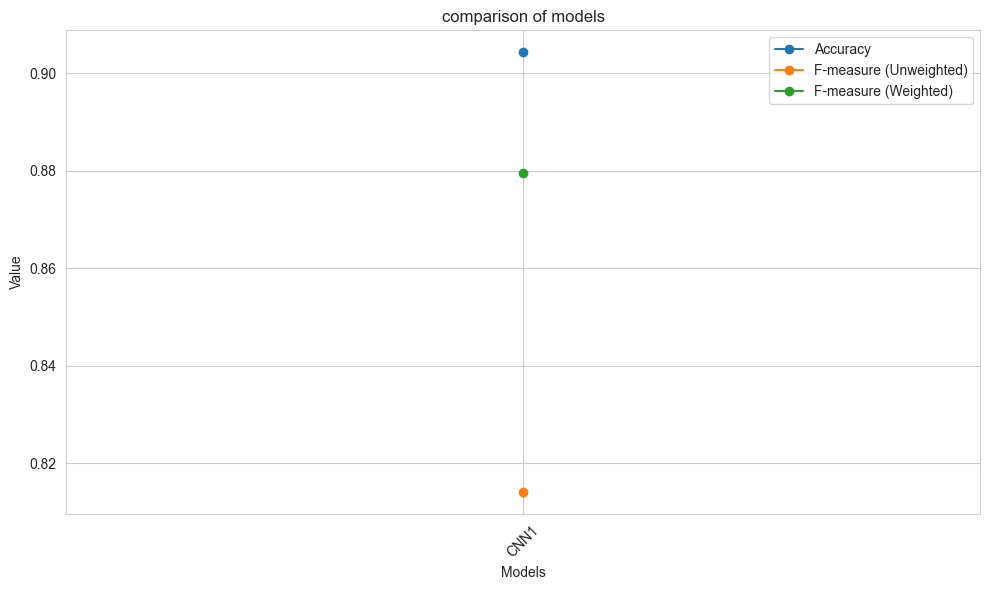

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")  # Seaborn way of setting style

# Compare accuracy and f-score
model_types = [result['model_type'] for result in model_results]
accuracies = [result['accuracy'] for result in model_results]
fmeasure_unweighted = [result['f-measure_unweighted'] for result in model_results]
fmeasure_weighted = [result['f-measure_weighted'] for result in model_results]

fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(model_types))

# Accuracy (accuracy)
ax.plot(x, accuracies, marker='o', label='Accuracy')

# F-score  (unweighted fmeasure)
ax.plot(x, fmeasure_unweighted, marker='o', label='F-measure (Unweighted)')

# F-score  (weighted fmeasure)
ax.plot(x, fmeasure_weighted, marker='o', label='F-measure (Weighted)')

ax.set_xticks(x)
ax.set_xticklabels(model_types, rotation=45)

ax.set_title('comparison of models')
ax.set_xlabel('Models')
ax.set_ylabel('Value')

ax.legend()
plt.tight_layout()
plt.show()


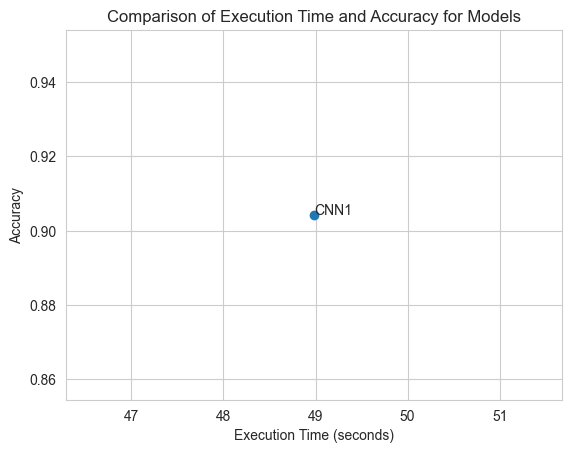

In [48]:
import matplotlib.pyplot as plt

execution_times = [result['execution_time'] for result in model_results]
accuracies = [result['accuracy'] for result in model_results]
model_types = [result['model_type'] for result in model_results]

# Create scatter plot
plt.scatter(execution_times, accuracies)

# Label each point with the model type
for i, model_type in enumerate(model_types):
    plt.annotate(model_type, (execution_times[i], accuracies[i]))

# Axis labels
plt.xlabel('Execution Time (seconds)')
plt.ylabel('Accuracy')

# Plot title
plt.title('Comparison of Execution Time and Accuracy for Models')

# Show the plot
plt.show()

In [57]:
model_results

[{'model_type': 'CNN1',
  'norm_type': None,
  'accuracy': 0.9042553191489362,
  'f-measure_unweighted': 0.8141109168917845,
  'f-measure_weighted': 0.8795919816344401,
  'execution_time': 48.987728118896484}]

In [61]:
# USING CONFIDENCE INTERVALS
from evaluation import CalculateCI, find_best_result

num_samples = test_data.shape[0]

"""
num_samples is the amount of test data if we use split into  train - test and
we use the total amount of data if we use cross validation
"""

model_type_to_search = 'CNN1'
best_index = find_best_result(model_type_to_search, model_results)

if best_index is not None:
    print(f"The best result for model type '{model_type_to_search}' is at index {best_index}.")
    print(model_results[best_index])
else:
    print(f"No results found for model type '{model_type_to_search}'.")

acc_cnn1 = 100*model_results[best_index]['accuracy']
CI_cnn1 = CalculateCI(num_samples, acc_cnn1)
print('[CNN1][accuracy = %0.2f (%0.2f, %0.2f)]' % (acc_cnn1, acc_cnn1-CI_cnn1, acc_cnn1+CI_cnn1))

The best result for model type 'CNN1' is at index 0.
{'model_type': 'CNN1', 'norm_type': None, 'accuracy': 0.9042553191489362, 'f-measure_unweighted': 0.8141109168917845, 'f-measure_weighted': 0.8795919816344401, 'execution_time': 48.987728118896484}
[CNN1][accuracy = 90.43 (84.48, 96.37)]


### Run only when evaluating with the CNN2 option

In [ ]:
model_type_to_search = 'CNN2'
best_index = find_best_result(model_type_to_search, model_results)

if best_index is not None:
    print(f"The best result for model type '{model_type_to_search}' is at index {best_index}.")
    print(model_results[best_index])
else:
    print(f"No results found for model type '{model_type_to_search}'.")

acc_cnn2 = 100*model_results[best_index]['accuracy']
CI_cnn2 = CalculateCI(num_samples, acc_cnn2)
print('[CNN2][accuracy = %0.2f (%0.2f, %0.2f)]' % (acc_cnn2, acc_cnn2-CI_cnn2, acc_cnn2+CI_cnn2))

### Run only when evaluating with the FINE-TUNNING1 option

In [ ]:
model_type_to_search = 'FINE-TUNING1'
best_index = find_best_result(model_type_to_search, model_results)

if best_index is not None:
    print(f"The best result for model type '{model_type_to_search}' is at index {best_index}.")
    print(model_results[best_index])
else:
    print(f"No results found for model type '{model_type_to_search}'.")

acc_fine_tunning1 = 100*model_results[best_index]['accuracy']
CI_fine_tunning1 = CalculateCI(num_samples, acc_fine_tunning1)
print('[FINE-TUNING1][accuracy = %0.2f (%0.2f, %0.2f)]' % (acc_fine_tunning1, acc_fine_tunning1-CI_fine_tunning1, acc_fine_tunning1+CI_fine_tunning1))

### Run only when evaluating with the FINE-TUNNING2 option

In [ ]:
model_type_to_search = 'FINE-TUNING2'
best_index = find_best_result(model_type_to_search, model_results)

if best_index is not None:
    print(f"The best result for model type '{model_type_to_search}' is at index {best_index}.")
    print(model_results[best_index])
else:
    print(f"No results found for model type '{model_type_to_search}'.")

acc_fine_tunning2 = 100*model_results[best_index]['accuracy']
CI_fine_tunning2 = CalculateCI(num_samples, acc_fine_tunning2)
print('[FINE-TUNING1][accuracy = %0.2f (%0.2f, %0.2f)]' % (acc_fine_tunning2, acc_fine_tunning2-CI_fine_tunning2, acc_fine_tunning2+CI_fine_tunning2))

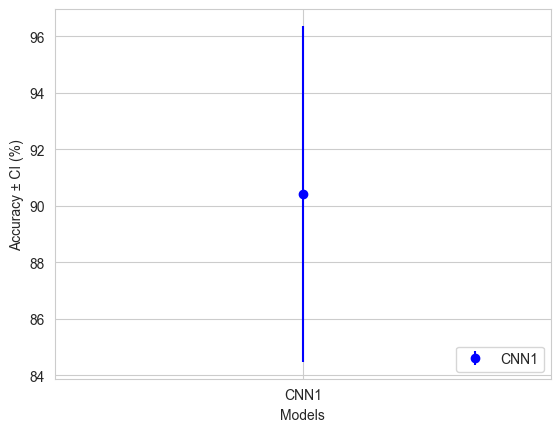

In [56]:
# PLOT RESULTS
import matplotlib.pyplot as plt
import numpy as np

# ARRAYS/INFO TO PLOT
means = [acc_cnn1]
CI = [CI_cnn1]
model_labels = ['CNN1']

# WITH FINETUNED MODELS
#means = [acc_cnn1, acc_cnn2, acc_fine_tunning1, acc_fine_tunning2]
#CI = [CI_cnn1, CI_cnn2, CI_fine_tunning1, CI_fine_tunning2]
#model_labels = ['CNN1', 'CNN2', 'FINE-TUNING1', 'FINE-TUNING2']


# PLOT DATA
fig, ax = plt.subplots(1)
plt.errorbar([0], [acc_cnn1], yerr=[CI_cnn1], fmt='o', label='CNN1', color="blue")
#plt.errorbar([1], [acc_cnn2], yerr=[CI_cnn2], fmt='o', label='CNN2', color="red")
#plt.errorbar([2], [acc_fine_tunning1], yerr=[CI_fine_tunning1], fmt='o', label='FINE-TUNNING1', color="green")
#plt.errorbar([3], [acc_fine_tunning2], yerr=[CI_fine_tunning2], fmt='o', label='FINE-TUNNING2', color="yellow")

#PLOT FORMAT
#plt.xlim(-0.5, 3.5)
plt.legend(loc='lower right')
plt.ylabel('Accuracy ± CI (%)')
plt.xlabel('Models')
plt.xticks(range(len(model_labels)), model_labels)

plt.show()